### Phase-based encoding in pairwise neural interactions

In [1]:
import os

In [2]:
import sys

sys.path.insert(1, os.path.join("/", *os.getcwd().split("/")[:-1]))

In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import copnorm_nd
from histogramMI import mutualInformationBin_jax
from hoi.core import get_mi
from mne.time_frequency.tfr import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

from src.models import simulate_kuramoto

/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [5]:
dt = 0.001  # Integration time-step
fs = 1 / dt
f = 40  # Natural frequency
beta = 2.5  # Noise variance
A = np.array([[0, 1], [0, 0]]).T
ntrials = 1_000
time = np.arange(-0.5, 1, 1 / fs)  # Time array
T = time.shape[0]

In [6]:
s = 8 / (2 * np.pi * f)

time_start = 0
time_end = 0.4
timestim = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
ind = np.where((time > time_start) & (time < time_end))[0]
gaussian = np.exp(-(timestim**2) / (2 * s**2))
coupling = np.zeros_like(time)
coupling[ind] = gaussian

# Coupling strength array (linearly spaced from 1 to 100)
CS = np.linspace(1, 100, ntrials)
seeds = np.random.randint(0, 100000, ntrials)

In [7]:
data = []

for trial in tqdm(range(ntrials)):
    data += [
        simulate_kuramoto(
            10 * A,
            np.zeros_like(A),
            coupling * CS[trial],
            f,
            fs,
            beta,
            T,
            seed=seeds[trial],
            decim=1,
        )
    ]

100%|███████████████████████████████| 1000/1000 [01:15<00:00, 13.33it/s]


In [8]:
h = scipy.signal.hilbert(np.stack(data).real, axis=2)

In [9]:
freqs = np.linspace(0.1, 80, 50)
W = tfr_array_morlet(
    data,
    fs / 1,
    freqs,
    n_cycles=freqs / 4,
    decim=1,
    output="complex",
    verbose=None,
)

In [10]:
Sxy = (W[:, 0] * np.conj(W[:, 1])).mean(0)
Sxx = (W[:, 0] * np.conj(W[:, 0])).mean(0)
Syy = (W[:, 1] * np.conj(W[:, 1])).mean(0)

coh = np.abs(Sxy) ** 2 / (Sxx * Syy)

In [11]:
mi_fcn = get_mi("gc")

mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))
mi_fcn_time_frequency = jax.vmap(mi_fcn_time, in_axes=(2, 2, None, None))

z = W[:, 0] * np.conj(W[:, 1])

dphi = np.angle(z)  # jnp.stack((z.real, z.imag))
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

labels = np.tile(
    np.expand_dims(np.arange(0, ntrials), (1, 2)), (z.shape[1], z.shape[2])
)


MI_PHI = mi_fcn_time_frequency(dphi[None], labels[None], False, True)

In [12]:
# dphi = jnp.stack((z.real, z.imag))
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

labels = np.tile(
    np.expand_dims(np.linspace(0, 100, ntrials), (1, 2)), (dphi.shape[1], dphi.shape[2])
)

x, y = dphi[None], labels[None]

In [13]:
mi_fcn_time_frequency = jax.vmap(mutualInformationBin_jax, in_axes=(2, 2, None, None))
nbins = 8
out = mi_fcn_time_frequency(x, y, nbins, "equiprobable")

In [14]:
def panzeri_treves_correction(I_obs, R, S, N):
    bias = ((R - 1) * (S - 1)) / (2 * N * np.log(2))
    return I_obs - bias

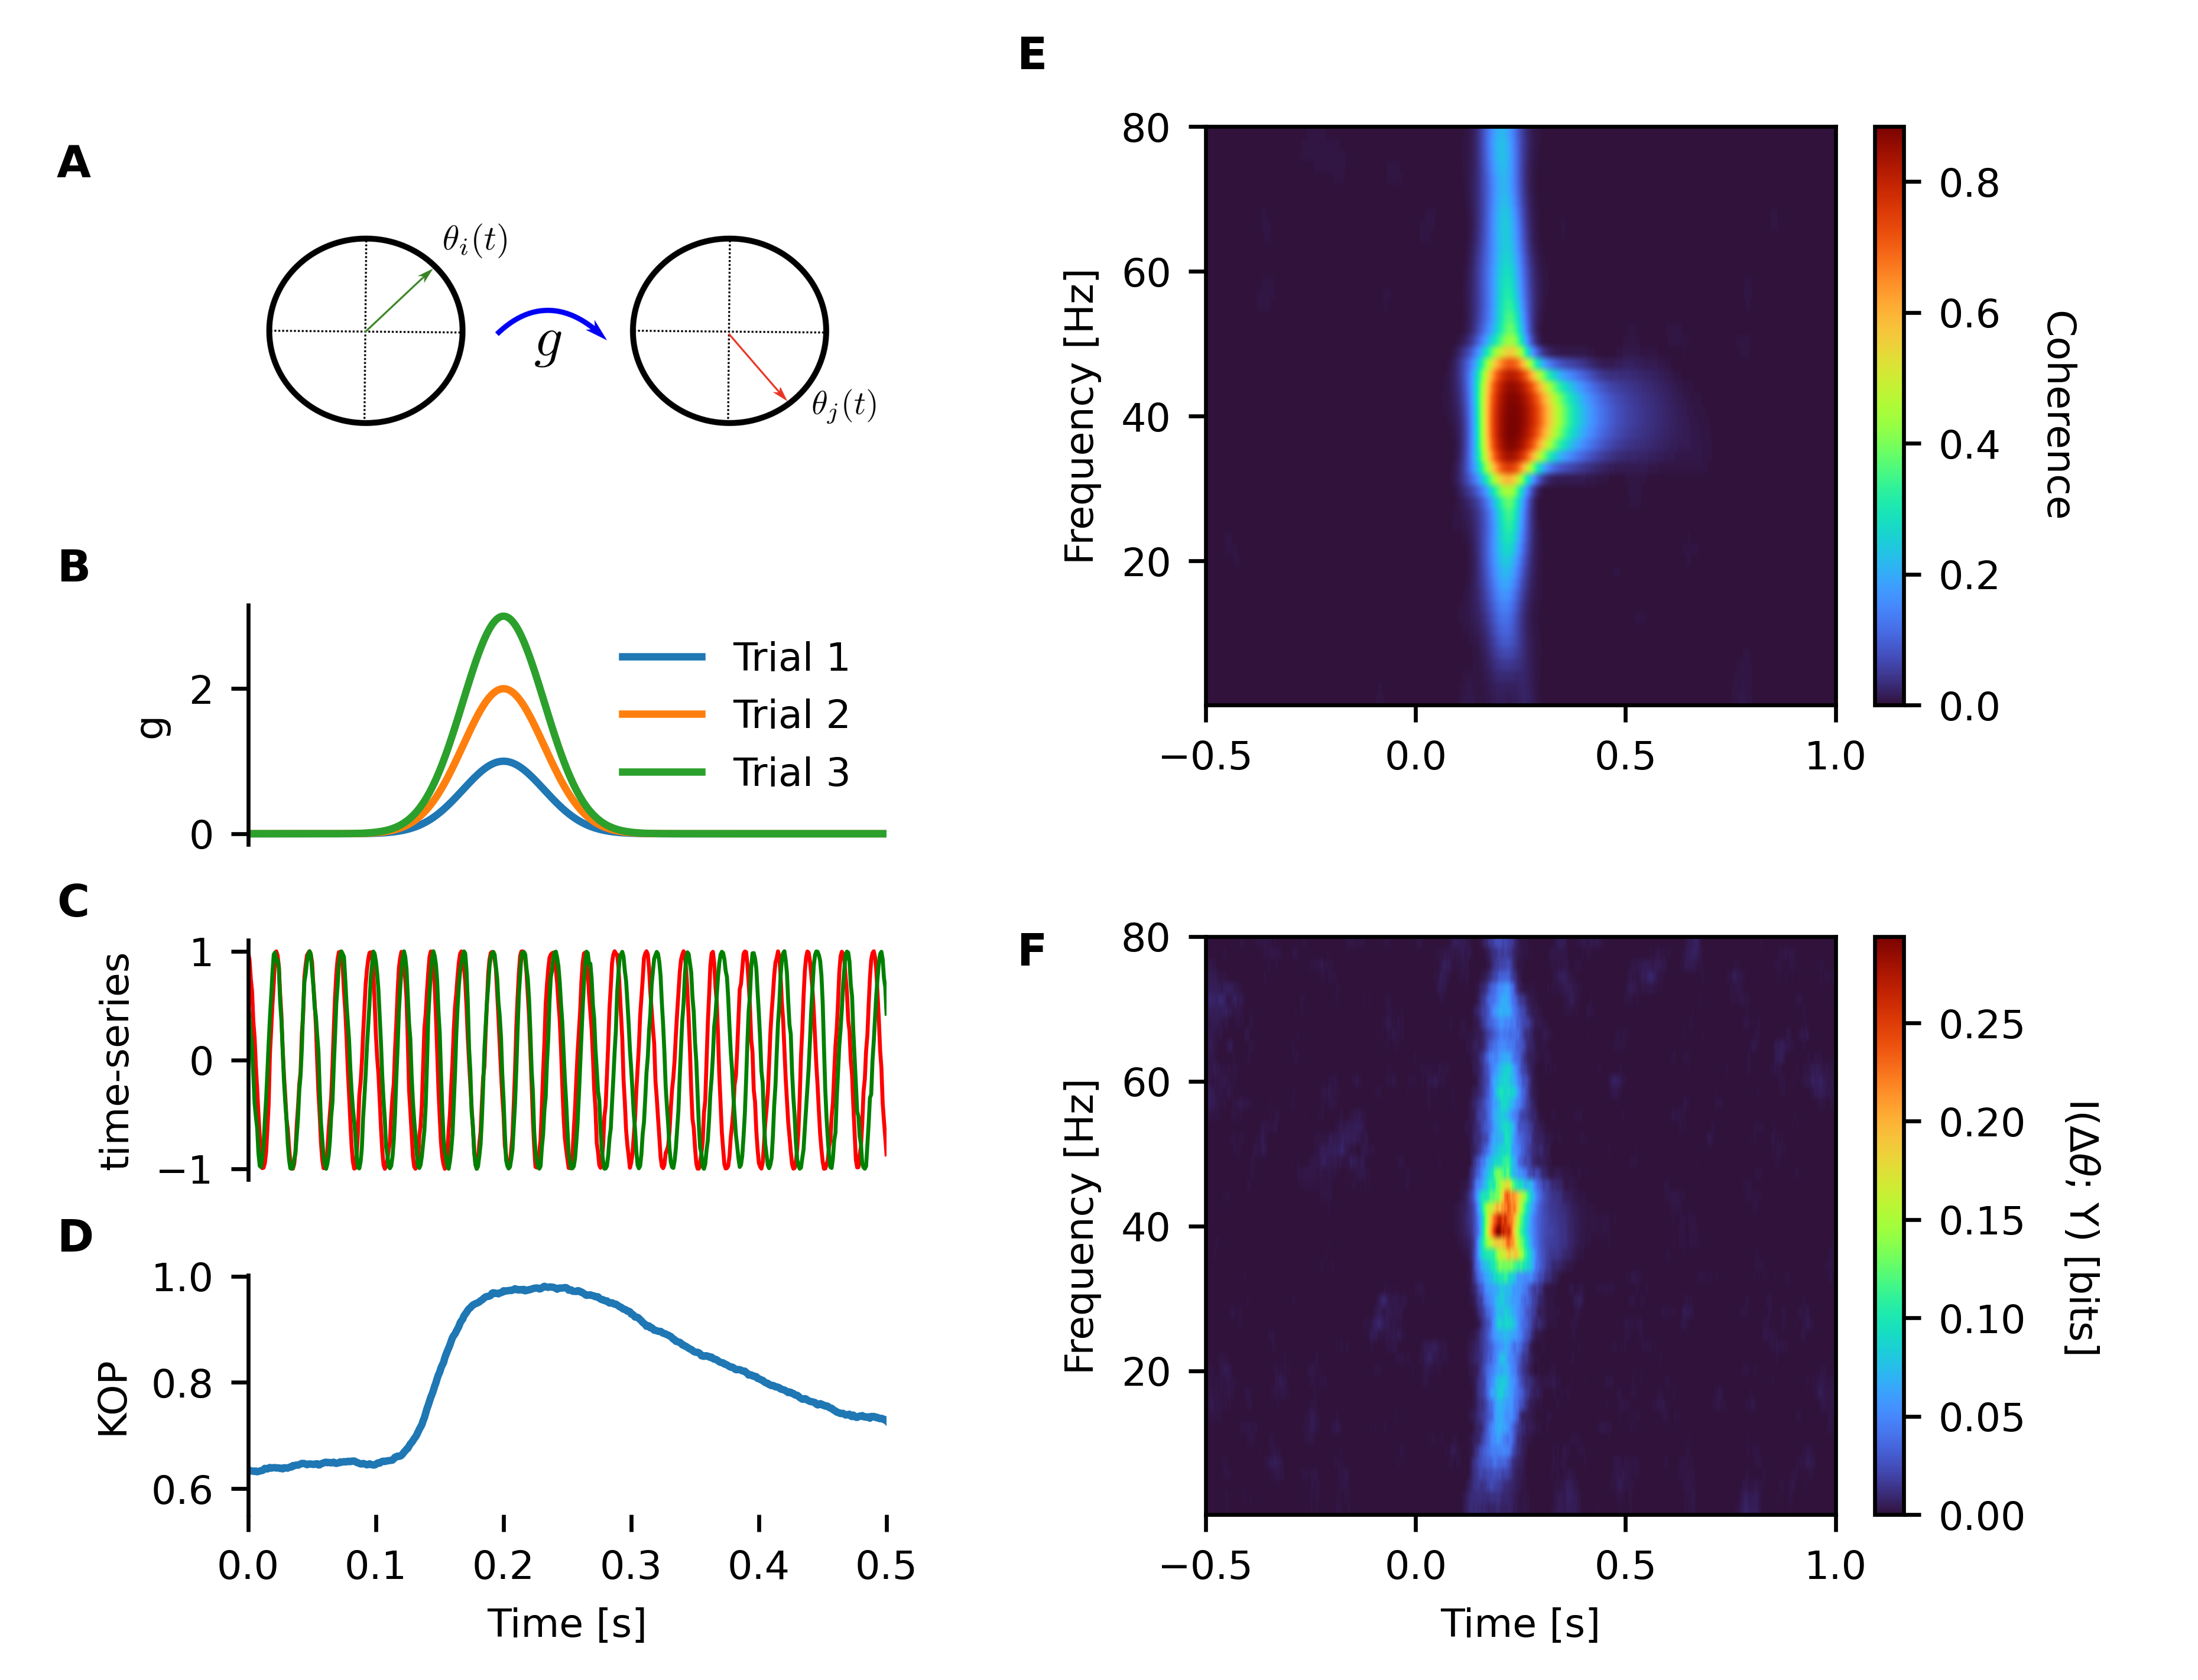

In [15]:
import plot
from PIL import Image

fig = plt.figure(figsize=(6.0, 4.5), dpi=600)

gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.1, right=0.4, bottom=0.7, top=0.95)
gs2 = fig.add_gridspec(
    nrows=3, ncols=1, left=0.1, right=0.4, bottom=0.08, top=0.65, hspace=0.4
)
gs3 = fig.add_gridspec(
    nrows=2, ncols=1, left=0.55, right=0.92, bottom=0.08, top=0.95, hspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])

# Panel B
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])
ax5 = plt.subplot(gs2[2])


# Panels C-E
ax6 = plt.subplot(gs3[0])
ax7 = plt.subplot(gs3[1])


###################################### DRAWING ######################################


# PANEL A
plt.sca(ax1)
im = Image.open("../Figures/kuramoto_cartoon.png")
plt.imshow(im)
plt.axis("off")


# PANEL B-E

plt.sca(ax2)
[plt.plot(time, coupling * i) for i in [1, 2, 3]]
[ax2.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.legend(["Trial 1", "Trial 2", "Trial 3"], frameon=False)
plt.xticks([])
plt.ylabel("g")
plt.xlim(0, 0.5)

plt.sca(ax3)
plt.plot(time[::1], data[250].real.T[:, 0], c="r", lw=0.8)
plt.xlim(0, 0.5)
plt.xticks([])
[ax3.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.ylabel("Node $i$")


plt.plot(time[::1], data[250].real.T[:, 1], c="g", lw=0.8)
plt.xlim(0, 0.5)
plt.xticks([])
[ax5.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.ylabel("time-series")

plt.sca(ax5)
plt.plot(time[::1], np.abs(h.mean(1)).mean(0))
[ax5.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]")
plt.ylabel("KOP")
plt.xlim(0, 0.5)


# PANEL F
plt.sca(ax6)
plt.imshow(
    coh.real,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[-0.5, 1, 0.1, 80],
    vmin=0,
)
cbar = plt.colorbar()
cbar.set_label("Coherence", rotation=270, labelpad=15)
plt.xlabel("")
plt.ylabel("Frequency [Hz]")

# PANEL G
plt.sca(ax7)
plt.imshow(
    MI_PHI,  # panzeri_treves_correction(out, nbins, nbins, ntrials),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[-0.5, 1, 0.1, 80],
    vmin=0,
)
cbar = plt.colorbar()
cbar.set_label(r"I($\Delta\theta$; Y) [bits]", rotation=270, labelpad=15)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")


# Background, labels, and annotations
bg = plot.Background(visible=False)
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3, ax5, ax6, ax7],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.3] * 6,
    ypos=[1.1] * 5 + [0.95] * 2,
)

plt.savefig("../Figures/Figure1.pdf")

Figure 1: Phase-based encoding in pairwise neural interactions. (A) Simulation of two Kuramoto oscillators
(see Eq. 13; using identical parameters for both nodes: ω = 2π40 Hz, η = 2.5, and coupling strength C12 = 10)
coupled via an undirected edge. The time series of the simulated dynamical system are represented by their
instantaneous phases θ(t) (depicted by green and red arrows in the unit circle). The coupling strength g(t) is
unidirectional from Xi to Xj. (B) The coupling strength g(t) between the two nodes was time-modulated such
that it was transiently non-zero from 0.1 to 0.3 s, following g(t) = 8Y/(2π f ), where Y was the maximum
coupling amplitude, increased from 1 to 100 across trials (n = 1000). (C) Time series of the simulated
Kuramoto nodes for the trial with the strongest coupling. (D) Kuramoto order parameter (KOP) time series
averaged across trials. (E) Time-frequency coherence spectrogram between the two nodes computed using
wavelet decomposition (ncycles = fc/ 4; for fc ∈ [0.1, 80] Hz). (F) Mutual information between the phase
difference of the two nodes (computed from the wavelet coefficients according to Eq. 10) and the coupling
amplitudes Y.